In [1]:
!nvidia-smi

Thu Nov 23 13:23:21 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 450.102.04   Driver Version: 450.102.04   CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  Off  | 00000000:85:00.0 Off |                    0 |
| N/A   36C    P0    59W / 300W |    609MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [2]:
!pip install --upgrade pip
#!pip install tensorflow[and-cuda]

In [3]:
#!python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"


In [4]:
import tensorflow as tf
print(tf.__version__)


2023-11-23 13:23:28.247232: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-23 13:23:30.809766: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2.13.1


In [5]:
!pip install GPUtil

In [6]:
import psutil
import GPUtil
import platform

def get_system_info():
    # RAM usage and capacity
    ram = psutil.virtual_memory()
    ram_usage = ram.percent
    ram_capacity = ram.total / (1024 ** 3)  # Convert to GB

    # CPU name
    cpu_name = platform.processor()

    # GPU/TPU name
    try:
        gpus = GPUtil.getGPUs()
        gpu_name = gpus[0].name
    except Exception as e:
        gpu_name = None

    return ram_usage, ram_capacity, cpu_name, gpu_name

ram_usage, ram_capacity, cpu_name, gpu_name = get_system_info()

print(f"RAM Usage: {ram_usage}%")
print(f"RAM Capacity: {ram_capacity:.2f} GB")
print(f"CPU Name: {cpu_name}")
if gpu_name:
    print(f"GPU Name: {gpu_name}")
else:
    print("GPU information not available.")


RAM Usage: 6.2%
RAM Capacity: 503.79 GB
CPU Name: x86_64
GPU Name: Tesla V100-SXM2-32GB


In [7]:
import torch

# Check if CUDA (GPU support) is available
if torch.cuda.is_available():
    # Get the number of available GPUs
    num_gpus = torch.cuda.device_count()
    
    print(f"Number of available GPUs: {num_gpus}")
    
    # Print the IDs of each GPU
    for gpu_id in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(gpu_id)
        print(f"GPU {gpu_id}: {gpu_name}")
else:
    print("No GPU devices available.")


Number of available GPUs: 1
GPU 0: Tesla V100-SXM2-32GB


In [8]:
!pip install pandas
!pip install scipy

In [9]:
import numpy as np
import pandas as pd
import os
from scipy import signal
import time

In [10]:
!ls

'(10-29-2023)-Adam.ipynb'  'Participant 10'		  'Participant 9'
'(10-29-2023)-SGD.ipynb'   'Participant 11 (only Cubes)'   ROC_plot
'(10-29-2023)-ftrl.ipynb'  'Participant 2'		   SAVE_MODEL
'(10-29-2023).ipynb'	   'Participant 3'		   SGD_output.csv
 Adam_output.csv	   'Participant 4'		   cuda_install.ipynb
 Channels.dat		   'Participant 5'		   output.csv
 Data_sets_Encephalan.zip  'Participant 6'		   text.h5
 MODEL			   'Participant 7'		   text.keras
'Participant 1'		   'Participant 8'


In [11]:
#!sudo apt-get install unzip

In [12]:
#!unzip Data_sets_Encephalan.zip

In [13]:
class EEG:
    def __init__(self, participant,datasets):
        self.int = {}
        self.delta = {}
        self.theta = {}
        self.alpha = {}
        self.beta = {}
        self.gamma = {}
        base = "/root/code/"
        intensities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
        for dataset in datasets:
            if dataset == "Mona Lisa":
                Dname = "/Figs for spectra"
                var1 = "/Backgr_int_"
                var2 = ".dat"
            else:
                Dname = "/Cubes for spectra"
                var1 = "/Backgr_int_"
                var2 = "_type_0.4.dat"
        for intensity in intensities:
            S = os.path.join(base, "Participant " + str(participant) + Dname + var1 + str(intensity) + var2)
            I = intensity
            self.int[I] = np.loadtxt(S)
            delta_signal = np.empty(self.int[I].shape)
            theta_signal =  np.empty(self.int[I].shape)
            alpha_signal = np.empty(self.int[I].shape)
            beta_signal = np.empty(self.int[I].shape)
            gamma_signal = np.empty(self.int[I].shape)
            for c in range(self.int[I].shape[1]):
                delta_signal[:,c], theta_signal[:,c],alpha_signal[:, c], beta_signal[:, c],gamma_signal[:,c] = self.fir_filtering(I, c)
            self.delta[I] = delta_signal
            self.theta[I] = theta_signal
            self.alpha[I] = alpha_signal
            self.beta[I] = beta_signal 
            self.gamma[I] = gamma_signal
    def fir_filtering(self, I, c):
        filter_delta = signal.firwin(400, [1.0, 4.0], pass_zero=False, fs=250)
        filter_theta = signal.firwin(400, [5.0, 8.0], pass_zero=False, fs=250)
        filter_alpha = signal.firwin(400, [8.0, 12.0], pass_zero=False, fs=250)
        filter_beta = signal.firwin(400, [13.0, 30.0], pass_zero=False, fs=250)
        filter_gamma = signal.firwin(400, [31.0, 45.0], pass_zero=False, fs=250)
        res_delta = signal.convolve(self.int[I][:, c], filter_delta, mode='same')
        res_theta = signal.convolve(self.int[I][:, c], filter_theta, mode='same')
        res_alpha = signal.convolve(self.int[I][:, c], filter_alpha, mode='same')
        res_beta = signal.convolve(self.int[I][:, c], filter_beta, mode='same')
        res_gamma = signal.convolve(self.int[I][:, c], filter_gamma, mode='same')
        return res_delta,res_theta, res_alpha,res_beta,res_gamma 

In [14]:
Intencity = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
base = "/root/code/"
file_path = os.path.join(base, "Channels.dat")
df_channels = pd.read_csv(file_path, header=None, sep='.')
channel_names = df_channels.iloc[:, -1:].values.flatten()

def convart_sin_fiq(fiq):
  if fiq == 'delta':
    return 1
  elif fiq == 'theta':
    return 2
  elif fiq == 'alpha':
    return 3
  elif fiq =='beta': 
    return 4
  elif fiq == 'gamma':
    return 5

def createdataframe(user,dataset,signal_fiq):
    global Intencity,channel_names
    tem_signal = []
    eeg_person = EEG(user,dataset)
    for i in Intencity:
        for ch in range(0,31):
         #   tem = [dataset,ch,channel_names[ch],convart_sin_fiq(signal_fiq),signal_fiq,i,user]
            tem = [channel_names[ch]]
            S = 'tem_signal.append(np.append(eeg_person.'+signal_fiq+'.get(i)[:,ch][0:15000],tem))'
            eval(S)
    
           
    tem_dataframe = pd.DataFrame(tem_signal)

    colunm = [] 

    for col in range(0,15000):
      S = 'Time'+str(col)
      colunm.append(S)

 #   colunm.append("Dataset")
 #   colunm.append("channel")
    colunm.append("Channel_Name")
 #   colunm.append("band")
#    colunm.append("frequency")
 #   colunm.append("Intencity")
#    colunm.append("participant")
    
    
    
    tem_dataframe.columns  = colunm 
    return tem_dataframe

In [15]:

def efficient_class(class_report):


# Calculate F1-score for class 0 and class 1
    f1_class_0 = class_report['0']['f1-score']
    f1_class_1 = class_report['1']['f1-score']

# Determine the most efficient class
    most_efficient_class = "left hemiparesis" if f1_class_0 > f1_class_1 else "right hemiparesis"
    return most_efficient_class

In [16]:
!pip install scikit-learn

In [17]:
from sklearn.metrics import roc_curve, auc
def ROC_plot(y_test_encoded,y_test_pred,name):

# Assuming y_test_encoded and y_test_pred are your true labels and predicted labels, respectively
# Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test_encoded, y_test_pred)

# Calculate Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)

# Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    file_name = 'ROC_plot/'+'ROC_plot_' +name+'.eps' # need chage also eps
    print(file_name)
    output_folder = 'ROC_plot'
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)
         
    

    plt.savefig(file_name,dpi=300)
    plt.show()
    return roc_auc

In [18]:
from sklearn.metrics import confusion_matrix
def specificity_fun(y_test_encoded,y_test_pred):
# Assuming y_test_encoded and y_test_pred are your true labels and predicted labels, respectively
    conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)

# Calculate specificity
    tn = conf_matrix[0, 0]  # True Negatives
    fp = conf_matrix[0, 1]  # False Positives

    specificity = tn / (tn + fp)
    return specificity

In [19]:
!pip install tensorflow
!pip install matplotlib
#!pip install --upgrade pip
#!pip install tensorflow[and-cuda]


In [20]:
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.python.client import device_lib

def run_model(data,name):

    y = data['binary_channel']
    X = data.drop(columns=['binary_channel'])
    X = X.apply(pd.to_numeric,errors='coerce')

    tf.keras.backend.clear_session()

    
    print(device_lib.list_local_devices())

    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)

# Split the data
    X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.7, random_state=42)
    X_valid, X_test, y_valid, y_test = train_test_split(X_rem, y_rem, test_size=0.5)

# Encode labels
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)

# Compute class weights
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

    X_train = X_train.astype(np.float32)
    y_train_encoded = y_train_encoded.astype(np.int32)

# Clear previous sessions
 #   tf.keras.backend.clear_session()

# Create the model
    model = Sequential()
    model.add(Dense(2500, input_shape=(X_train.shape[1],), activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(1000, activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(500, activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(200, activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(100, activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(50, activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(25, activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(15, activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(10, activation='tanh'))
    model.add(BatchNormalization())
    model.add(Dense(1, activation='sigmoid'))

# Use ftrl optimizer
    optimizer = tf.keras.optimizers.Ftrl(
    learning_rate=0.001,
    learning_rate_power=-0.5,
    initial_accumulator_value=0.1,
    l1_regularization_strength=0.0,
    l2_regularization_strength=0.0,
    name="Ftrl")


    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    model.summary()

# Early stopping callback
    callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=30)

    start_time = time.time()


# Train the model with class weights
    with tf.device('/GPU:0'):
        history = model.fit(X_train, y_train_encoded, epochs=200, batch_size=8, verbose=2, 
                        validation_data=(X_valid, y_valid), callbacks=[callback], 
                        class_weight=class_weight_dict)

    end_time = time.time()
    elapsed_time = end_time - start_time

# Evaluate on test data
    y_test_pred = model.predict(X_test).round().astype(int)  # Round probabilities to 0 or 1
    y_test_encoded = label_encoder.transform(y_test)

    classificationReport = classification_report(y_test_encoded, y_test_pred)
    print(classificationReport)
    class_report = classification_report(y_test_encoded, y_test_pred, output_dict=True)


    class_report_lines = classificationReport.split('\n')
    metrics = class_report_lines[2].split()
    precision = float(metrics[1])
    recall = float(metrics[2])
    f1_score = float(metrics[3])

    metrics_dict = {
    'Precision': precision, #done
    'Recall': recall, #done
    'F1-Score': f1_score, #done
    'Specificity': specificity_fun(y_test_encoded,y_test_pred), #done
    'Time': elapsed_time, # done
    'ROC AUC': ROC_plot(y_test_encoded,y_test_pred,name), #done
    'Most Efficient Class': efficient_class(class_report) # done
    }

# Plot training history
    plt.figure(dpi=300)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_accuracy'])
    plt.plot(history.history['val_loss'])


    plt.title('model and val accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['accuracy', 'loss','val_accuracy','val_loss'], loc='best')
    file_save_name = 'MODEL/model_auc_' + name + '.eps'
    output_folder = 'MODEL'
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)
    plt.savefig(file_save_name, format='eps', bbox_inches='tight', pad_inches=0.1)
    plt.show()
    return model,X_test,metrics_dict


In [21]:
!pip install shap

In [22]:


import shap
import matplotlib.pyplot as plt

def SHAP_plt(model, X_test, file_name):
    # Assuming your model is named 'model' and X_test contains the test data
    explainer = shap.Explainer(model)
    shap_values = explainer.shap_values(X_test[1:5])

    # Generate summary plot with higher DPI for better quality (e.g., 300 DPI)
    fig, ax = plt.subplots(dpi=300)
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=20)  # Set max_display to the number of features you want to display

    # Customize the plot if needed
    plt.title('SHAP Summary Plot')  # Add your desired title
    plt.xlabel('SHAP Value')  # Add your desired x-axis label
    plt.ylabel('Feature Names')  # Add your desired y-axis label

    # Save the customized plot as an EPS file with maximum SPI (Scalable PostScript Interchange)
    file_save_name = 'SHAP_PLOT/' + 'SHAP_' + file_name + '.eps'
    output_folder = 'SHAP_PLOT'
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)
    plt.savefig(file_save_name, format='eps', bbox_inches='tight', pad_inches=0.1)
    plt.show()
    return 0




In [23]:
def create_binary(data):
    data['binary_channel'] = data['Channel_Name'].apply(lambda x: 0 if '-A1' in x else 1 if '-A2' in x else None)
    return data.drop(columns = ['Channel_Name'])

Pre-Process time=  316.18667793273926
fig=  delta dataset=  Mona Lisa


2023-11-23 13:31:22.970792: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2023-11-23 13:31:23.266864: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6207163013985656961
xla_global_id: -1
]
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               5

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
The PostScript backend does not support transparency; partially transparent artists will

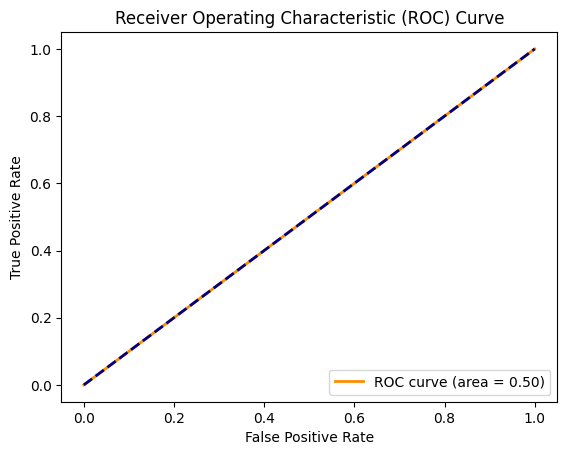

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


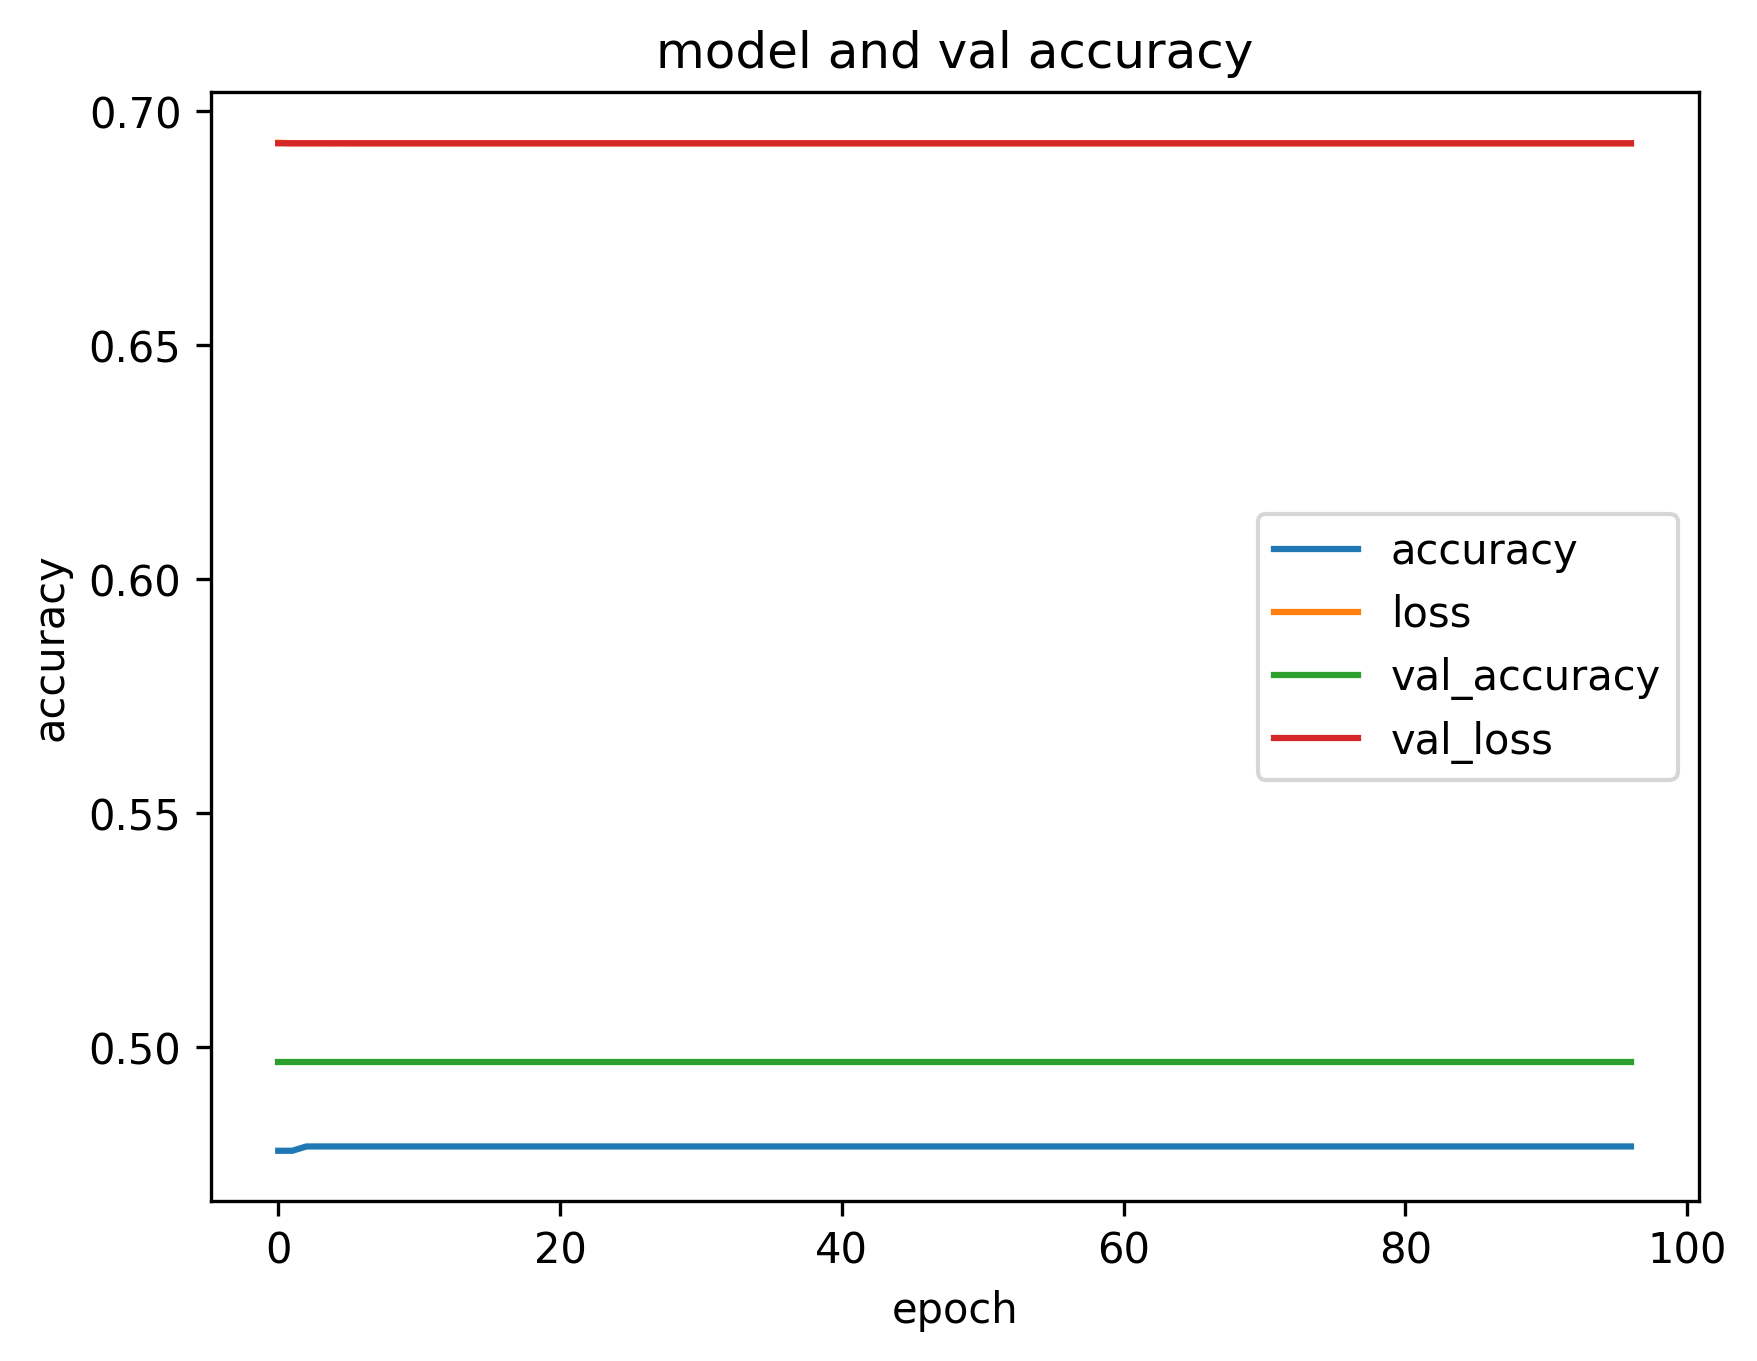

Pre-Process time=  308.7536153793335
fig=  theta dataset=  Mona Lisa
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 15605323474847018088
xla_global_id: -1
]


2023-11-23 17:20:25.762009: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       248
           1       0.47      1.00      0.64       217

    accuracy                           0.47       465
   macro avg       0.23      0.50      0.32       465
weighted avg       0.22      0.47      0.30       465

ROC_plot/ROC_plot_FTRL_theta_Mona Lisa.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


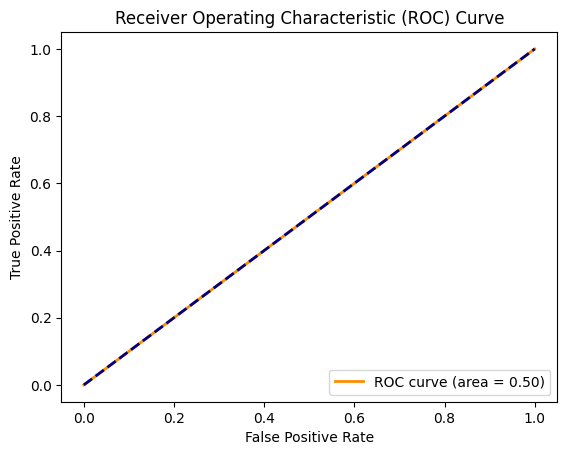

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


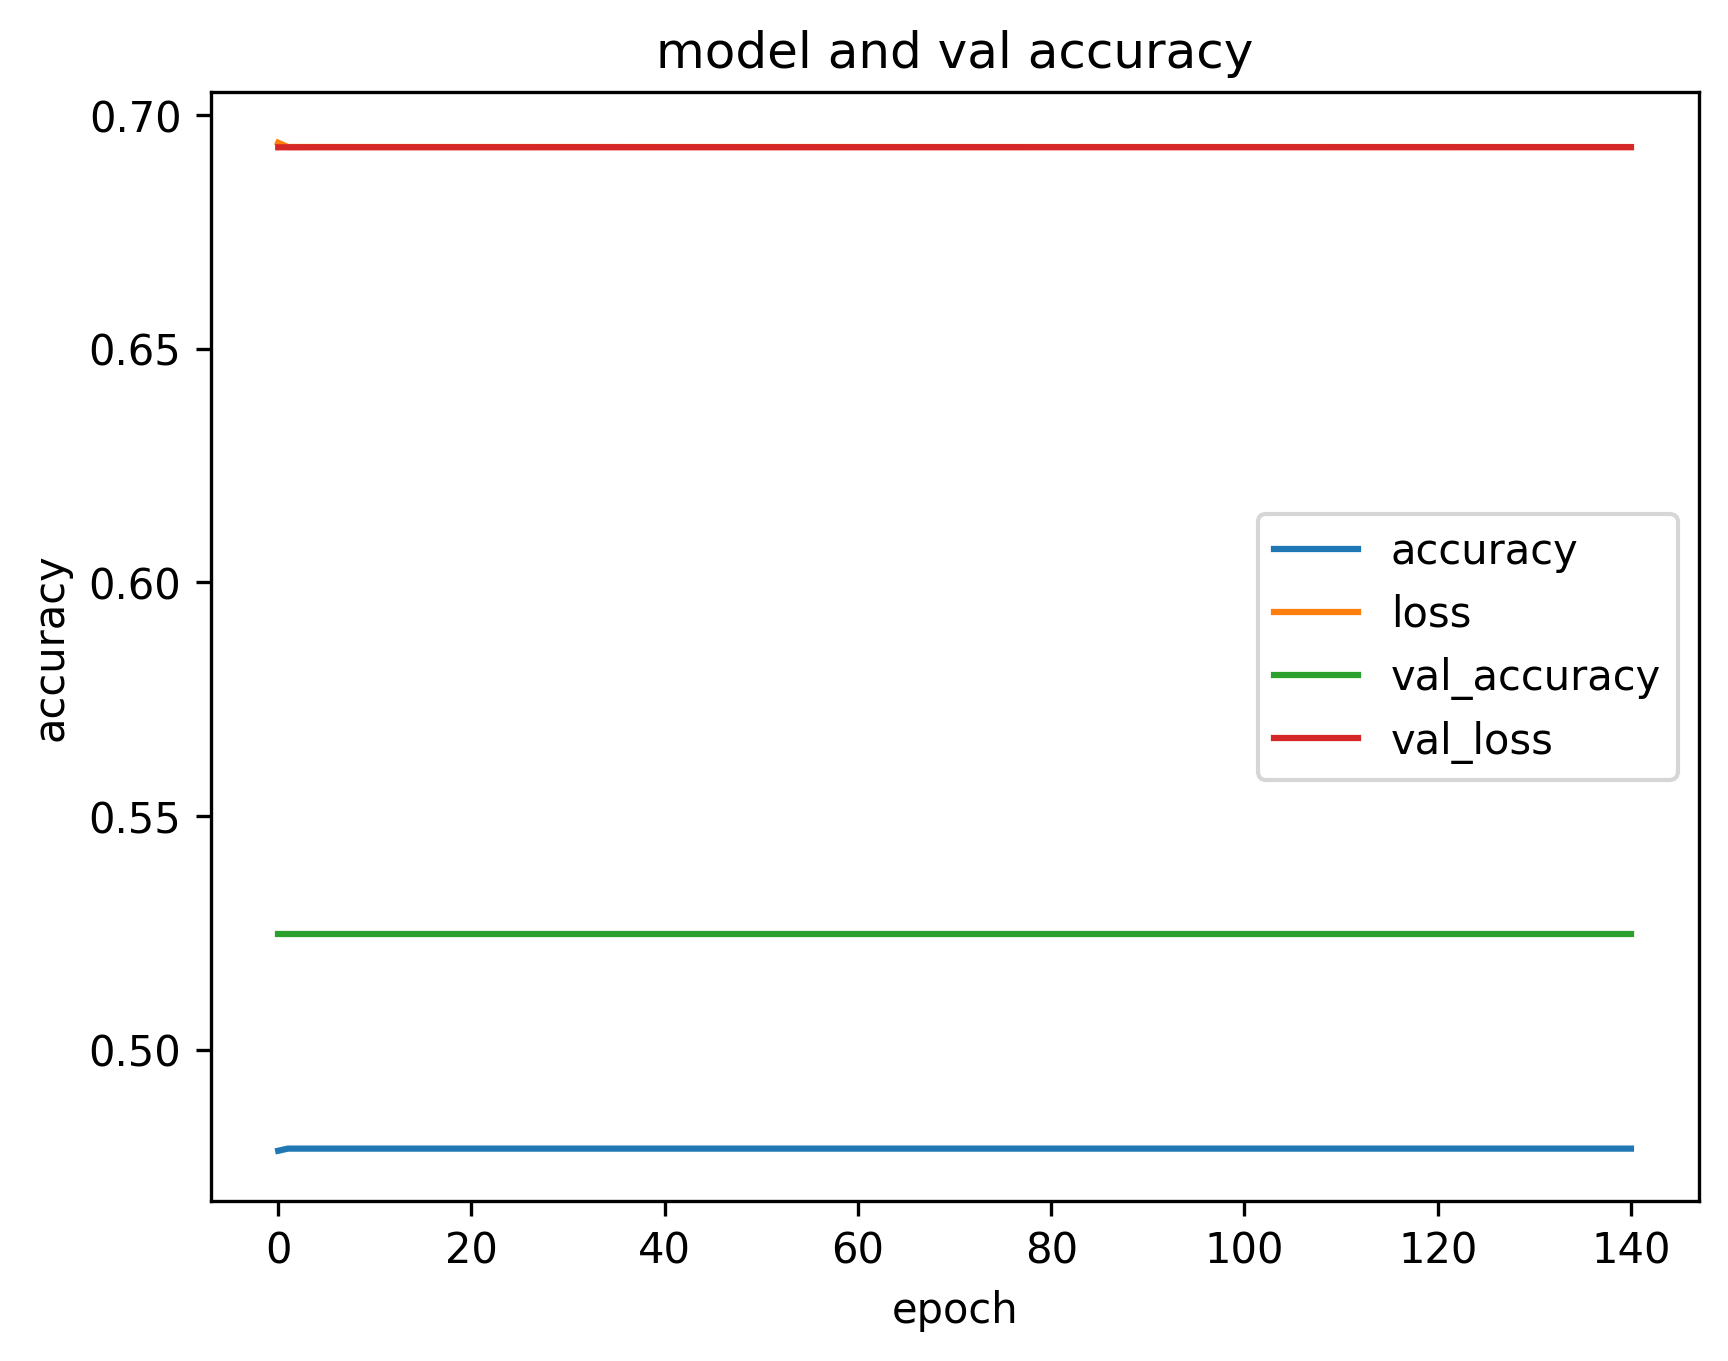

Pre-Process time=  319.8630123138428
fig=  alpha dataset=  Mona Lisa
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 14539664835101320101
xla_global_id: -1
]


2023-11-23 22:32:54.575713: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


ROC_plot/ROC_plot_FTRL_alpha_Mona Lisa.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


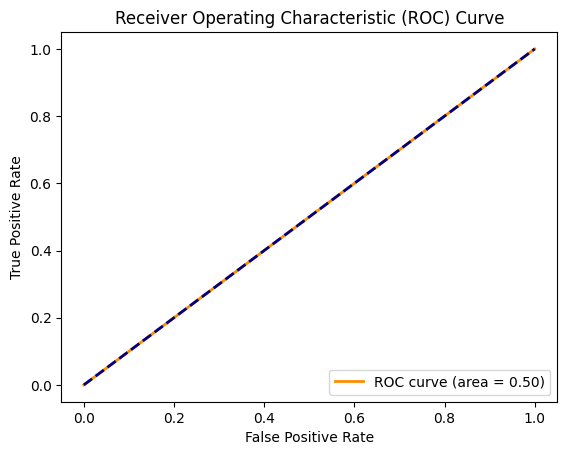

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


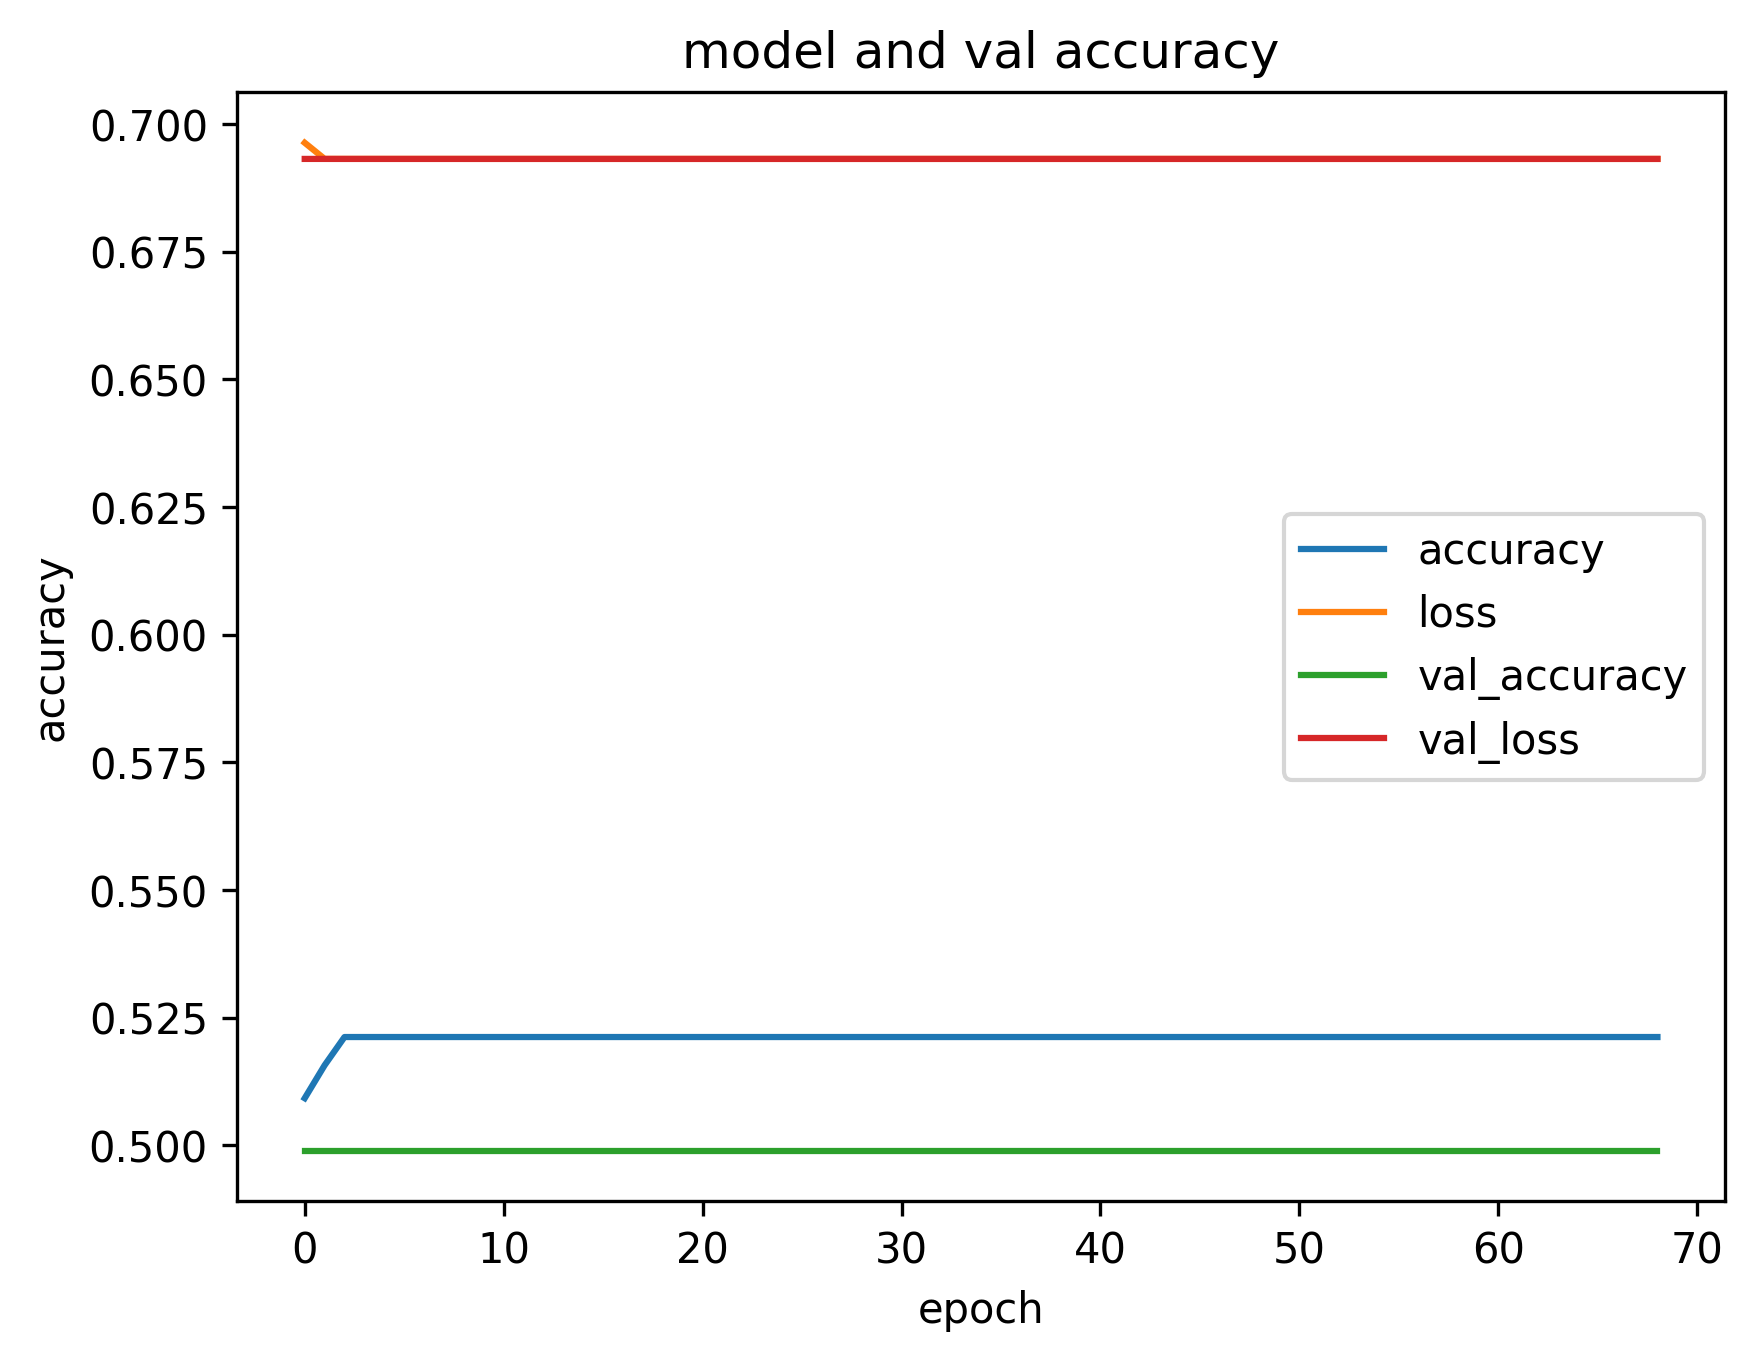

Pre-Process time=  311.08802795410156
fig=  beta dataset=  Mona Lisa
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16850833889583880698
xla_global_id: -1
]


2023-11-24 01:10:08.451201: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


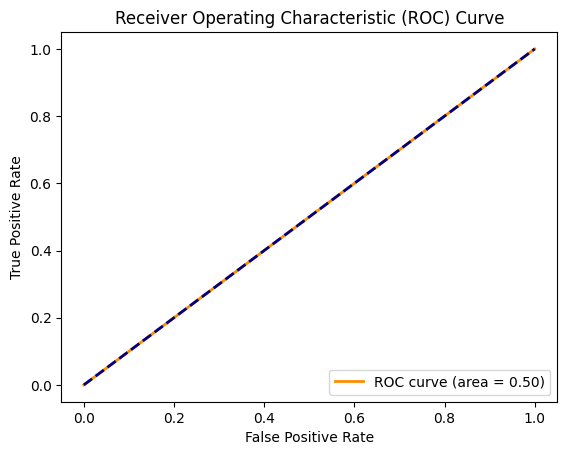

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


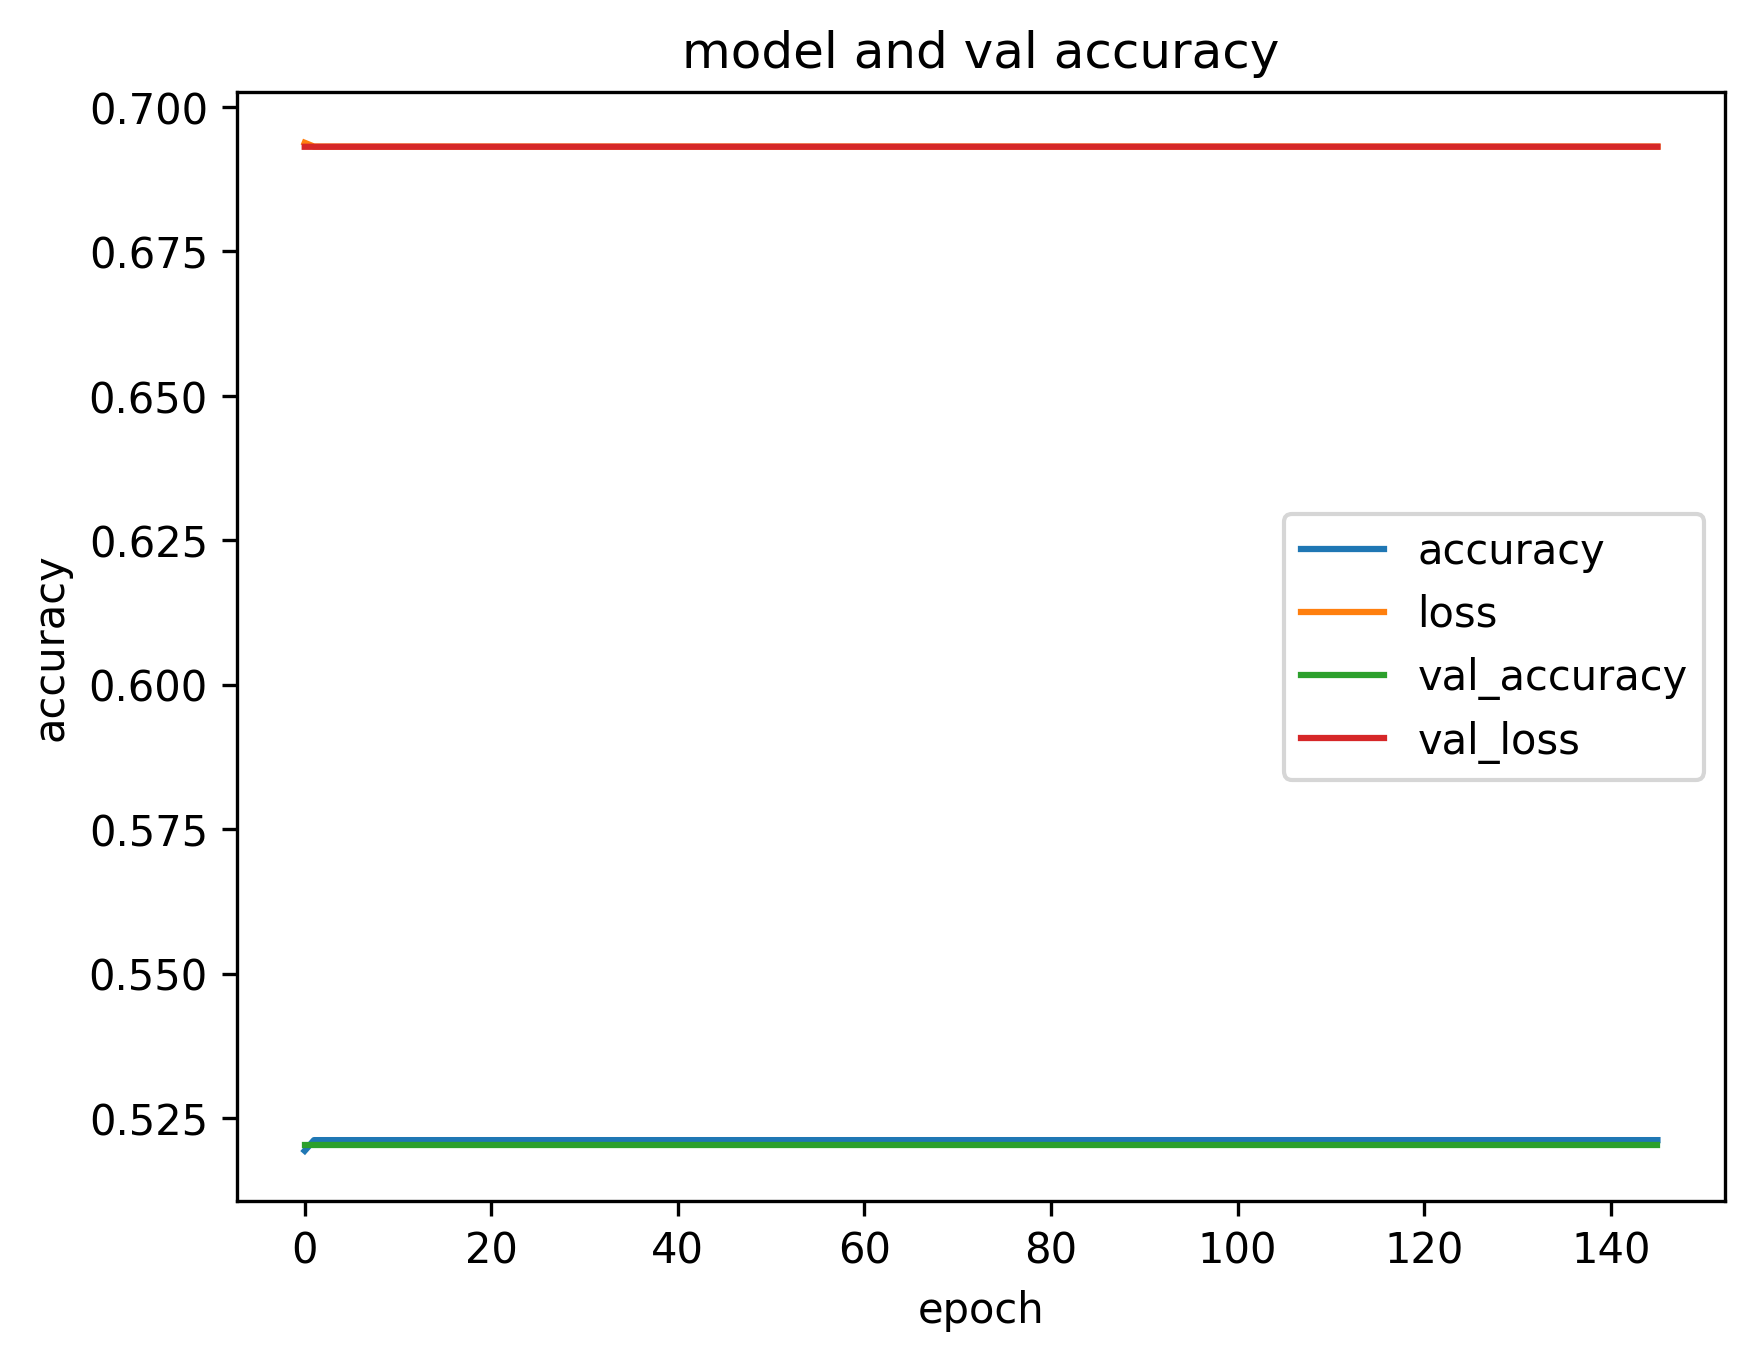

Pre-Process time=  311.3888683319092
fig=  gamma dataset=  Mona Lisa
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 15364148990590338330
xla_global_id: -1
]


2023-11-24 06:39:22.574704: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


ROC_plot/ROC_plot_FTRL_gamma_Mona Lisa.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


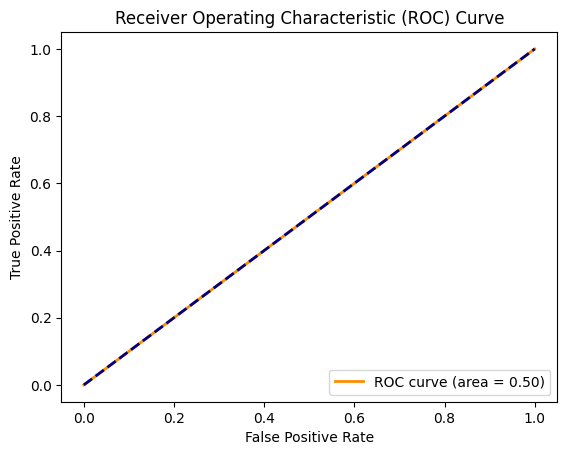

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


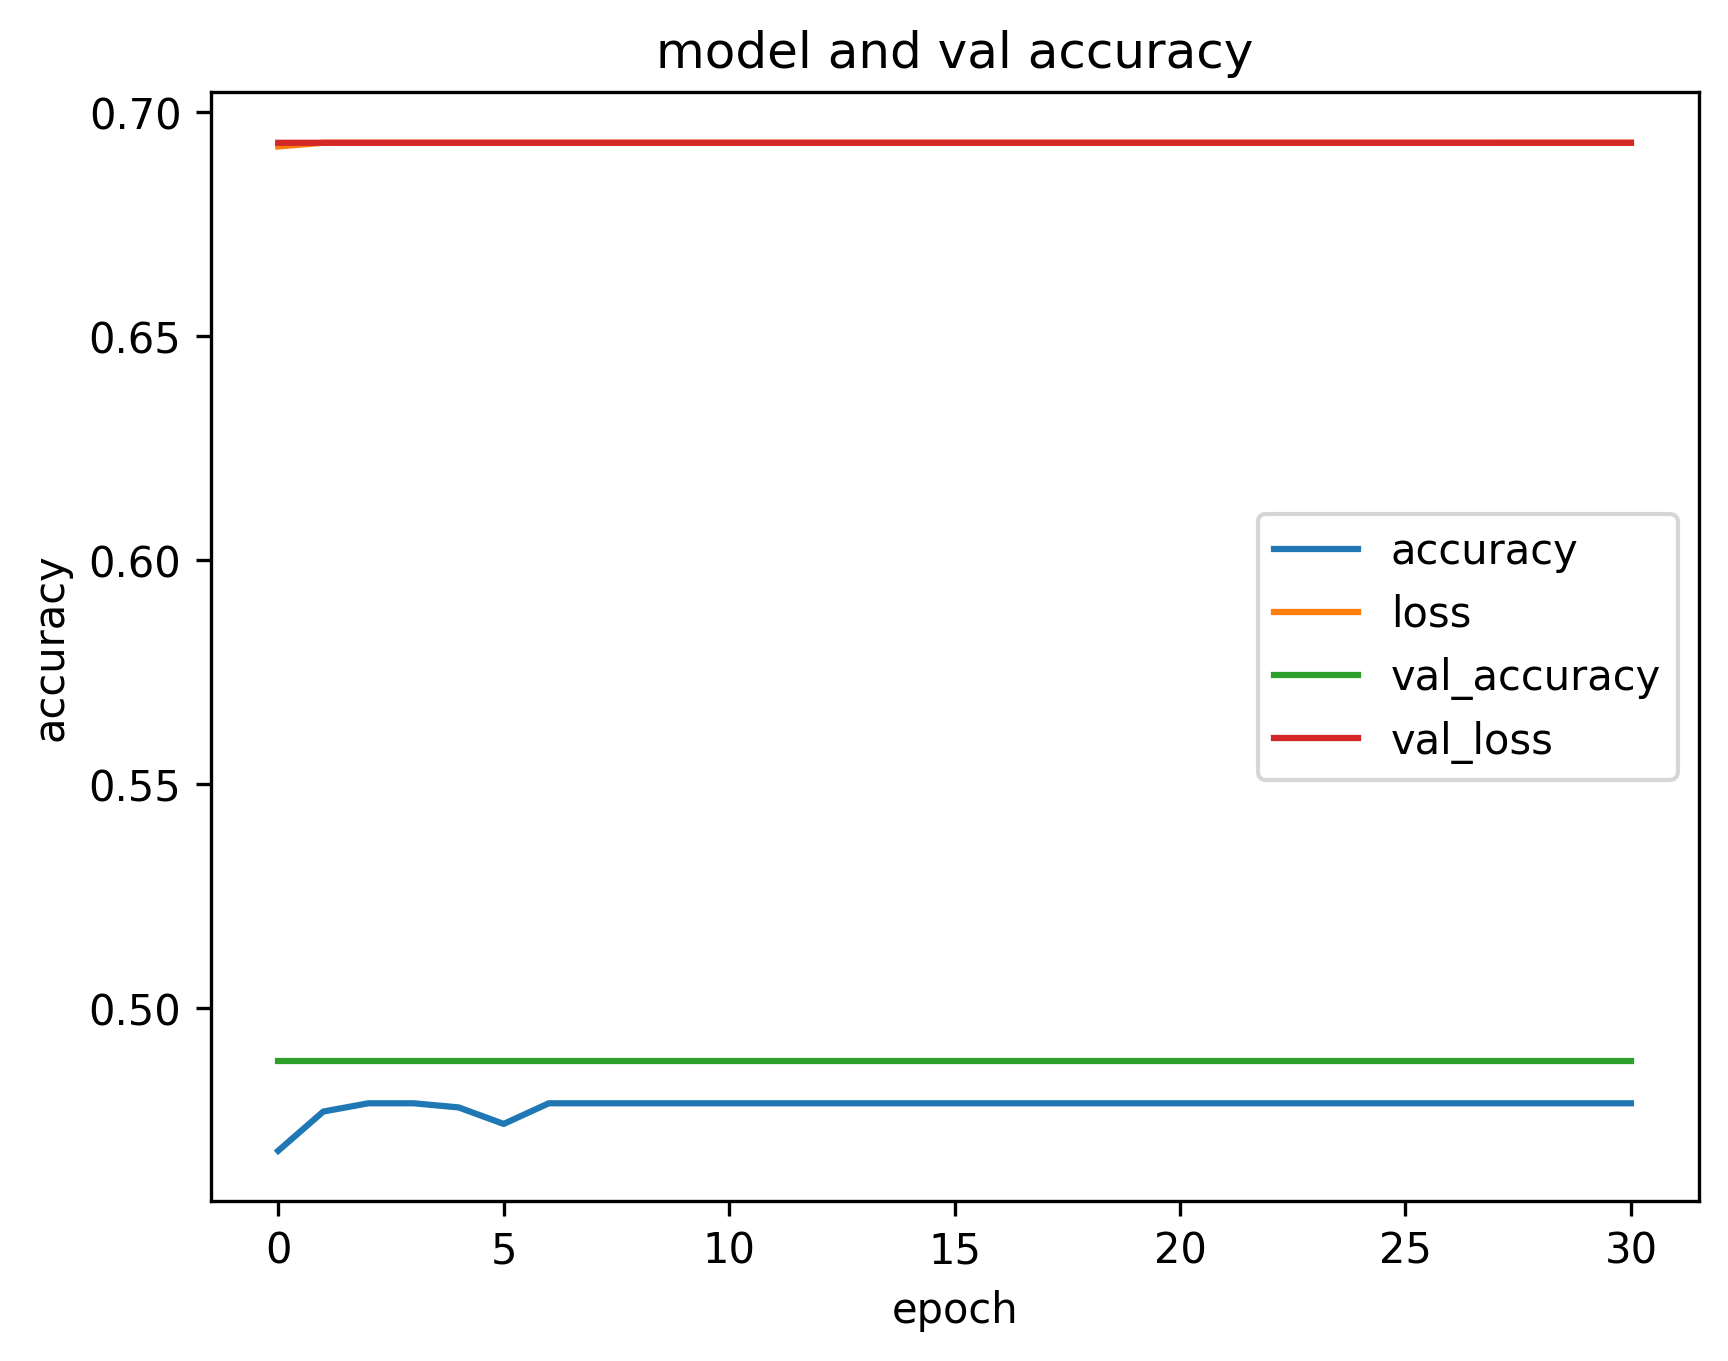

Pre-Process time=  314.82846665382385
fig=  delta dataset=  Necker cube
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2054599108472409299
xla_global_id: -1
]


2023-11-24 07:56:21.936173: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
The PostScript backend does not support transparency; partially transparent artists will

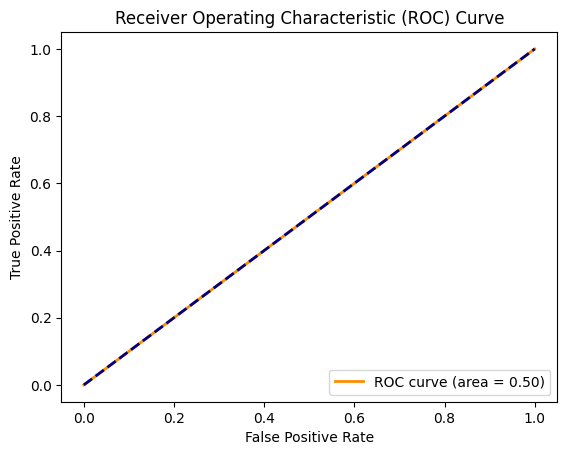

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


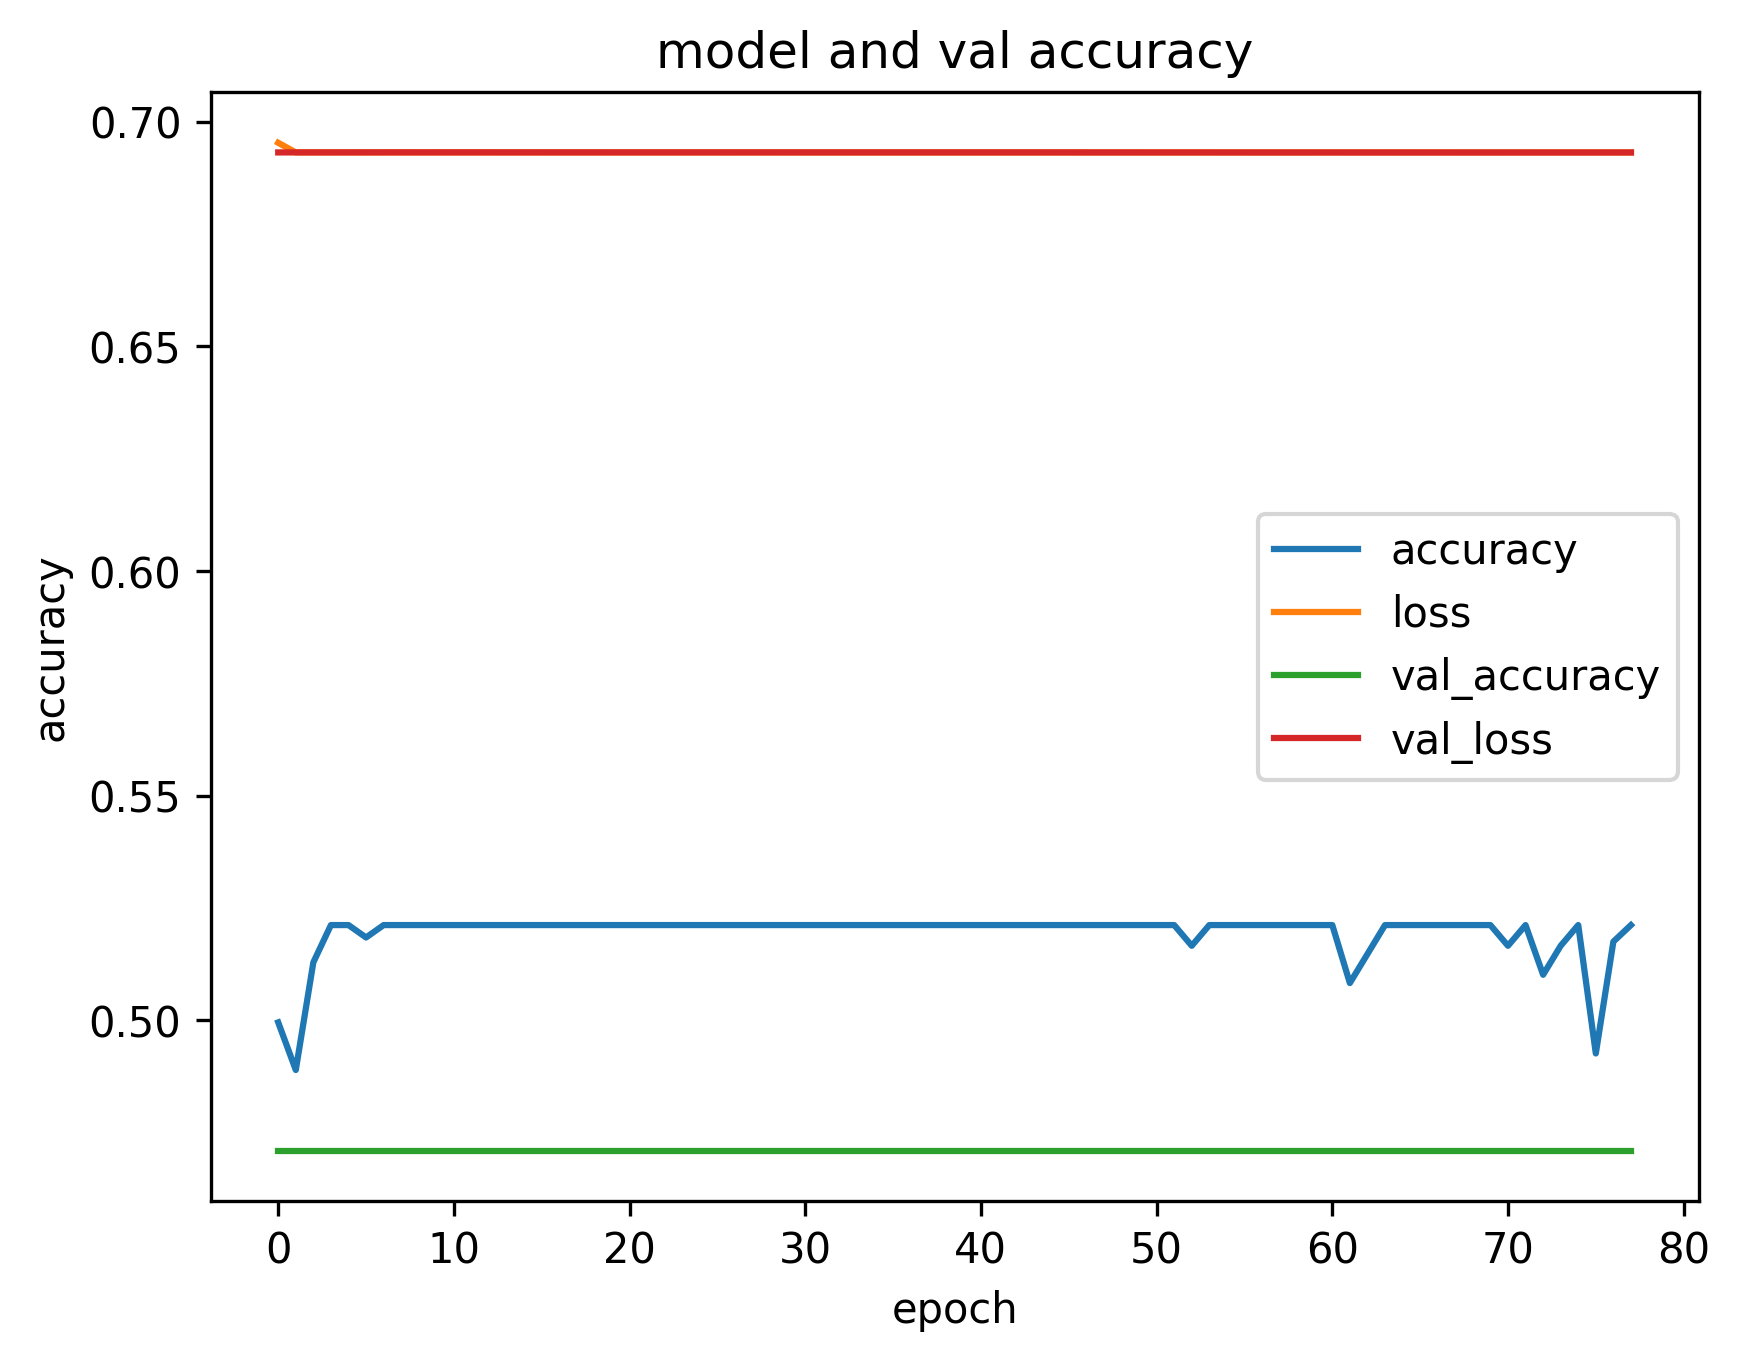

Pre-Process time=  308.1583833694458
fig=  theta dataset=  Necker cube
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 11304127797352721191
xla_global_id: -1
]


2023-11-24 10:52:48.461245: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
The PostScript backend does not support transparency; partially transparent artists will

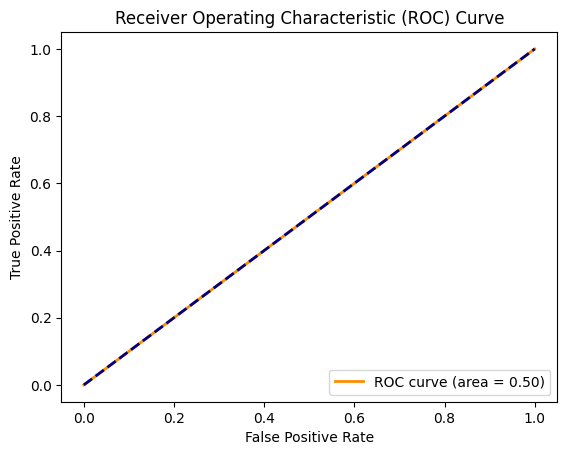

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


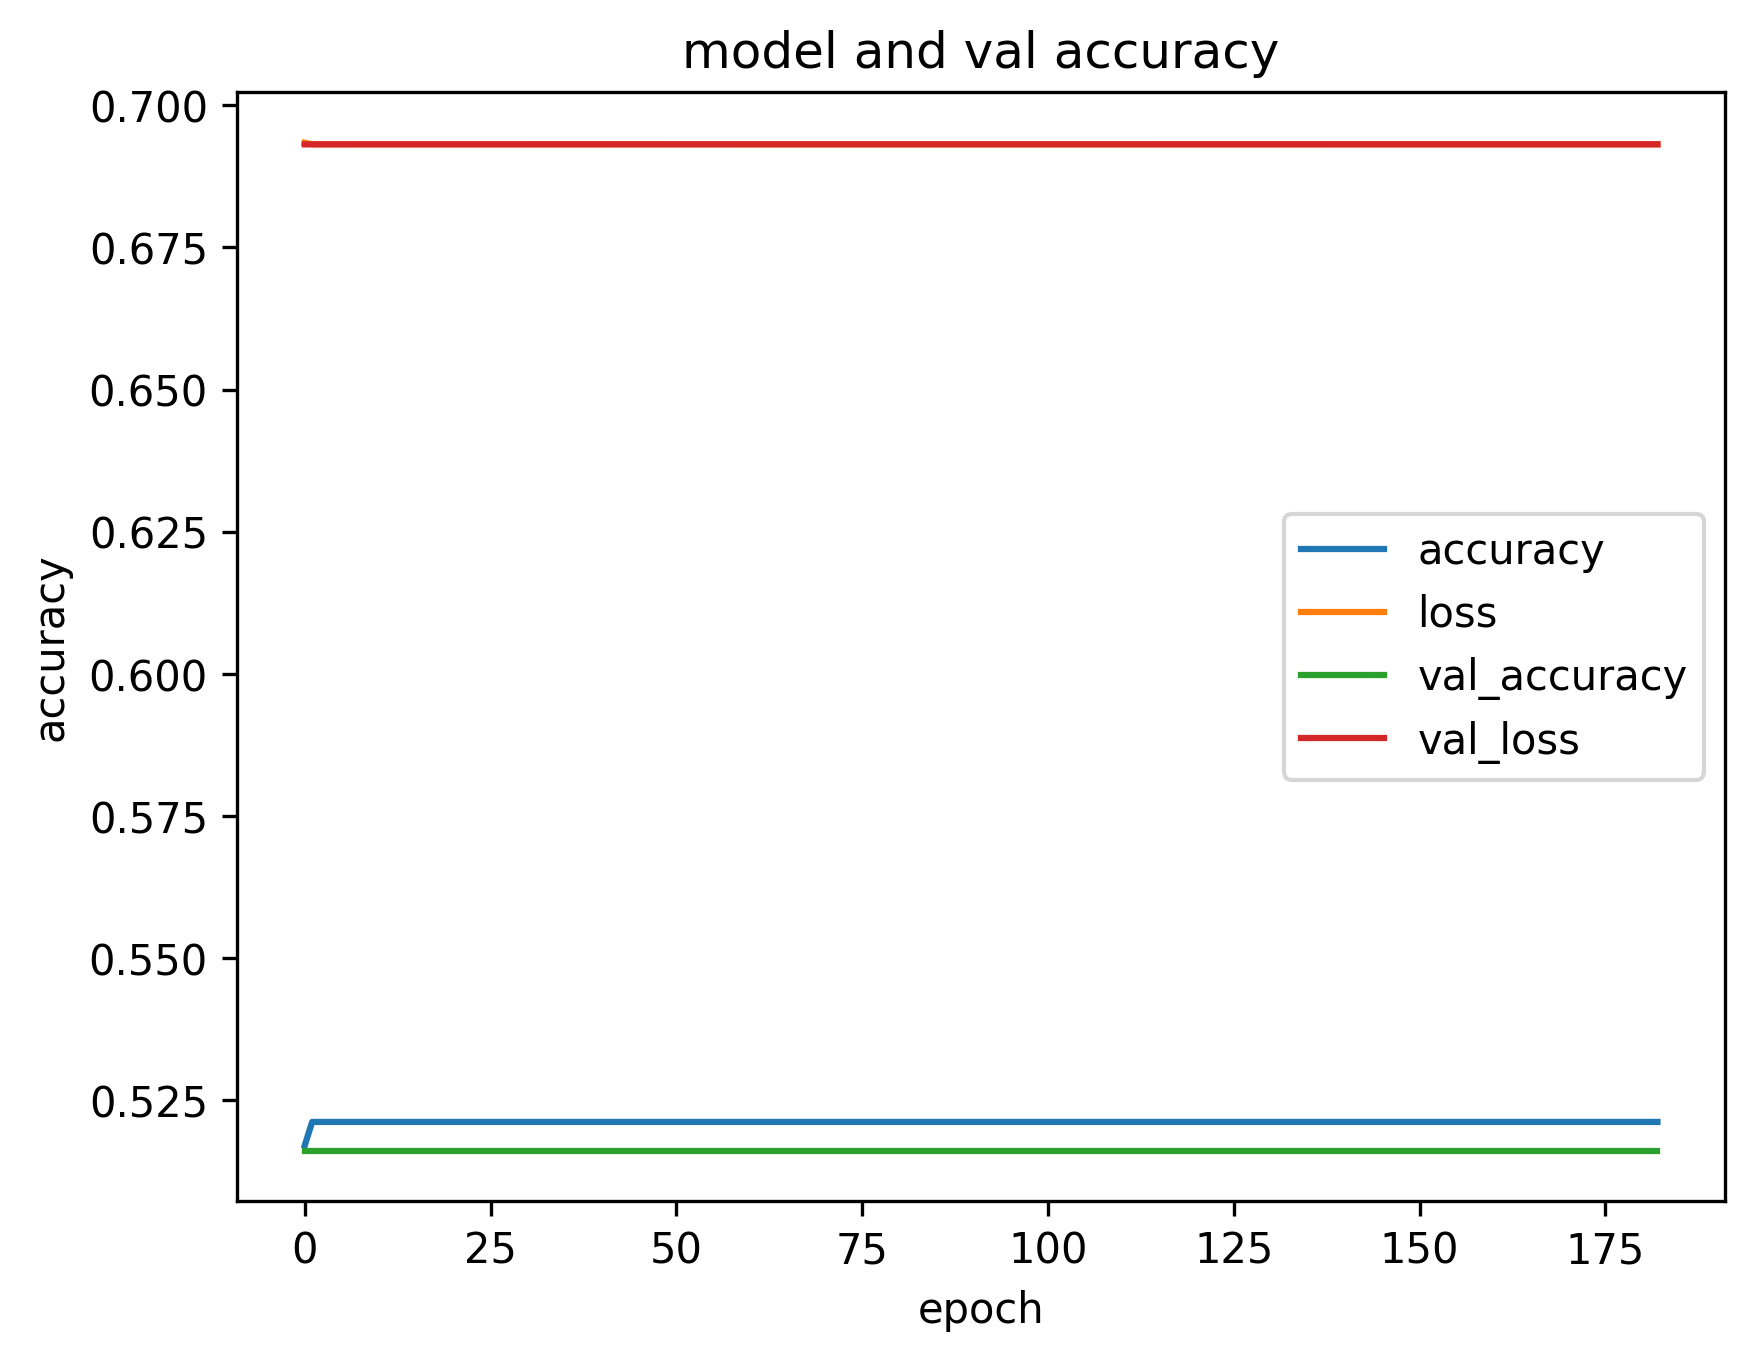

Pre-Process time=  307.59766459465027
fig=  alpha dataset=  Necker cube
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 12644602258544915485
xla_global_id: -1
]


2023-11-24 17:40:08.123807: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
The PostScript backend does not support transparency; partially transparent artists will

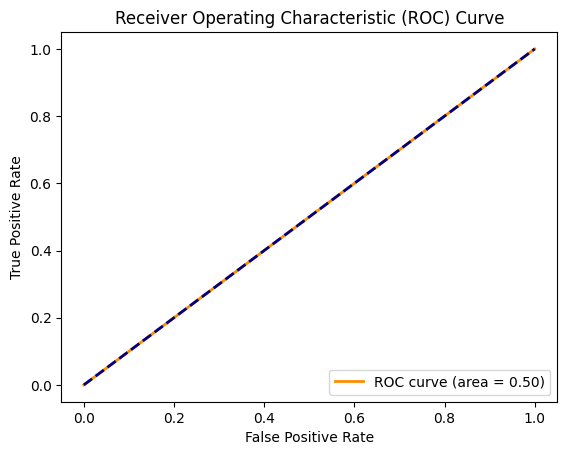

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


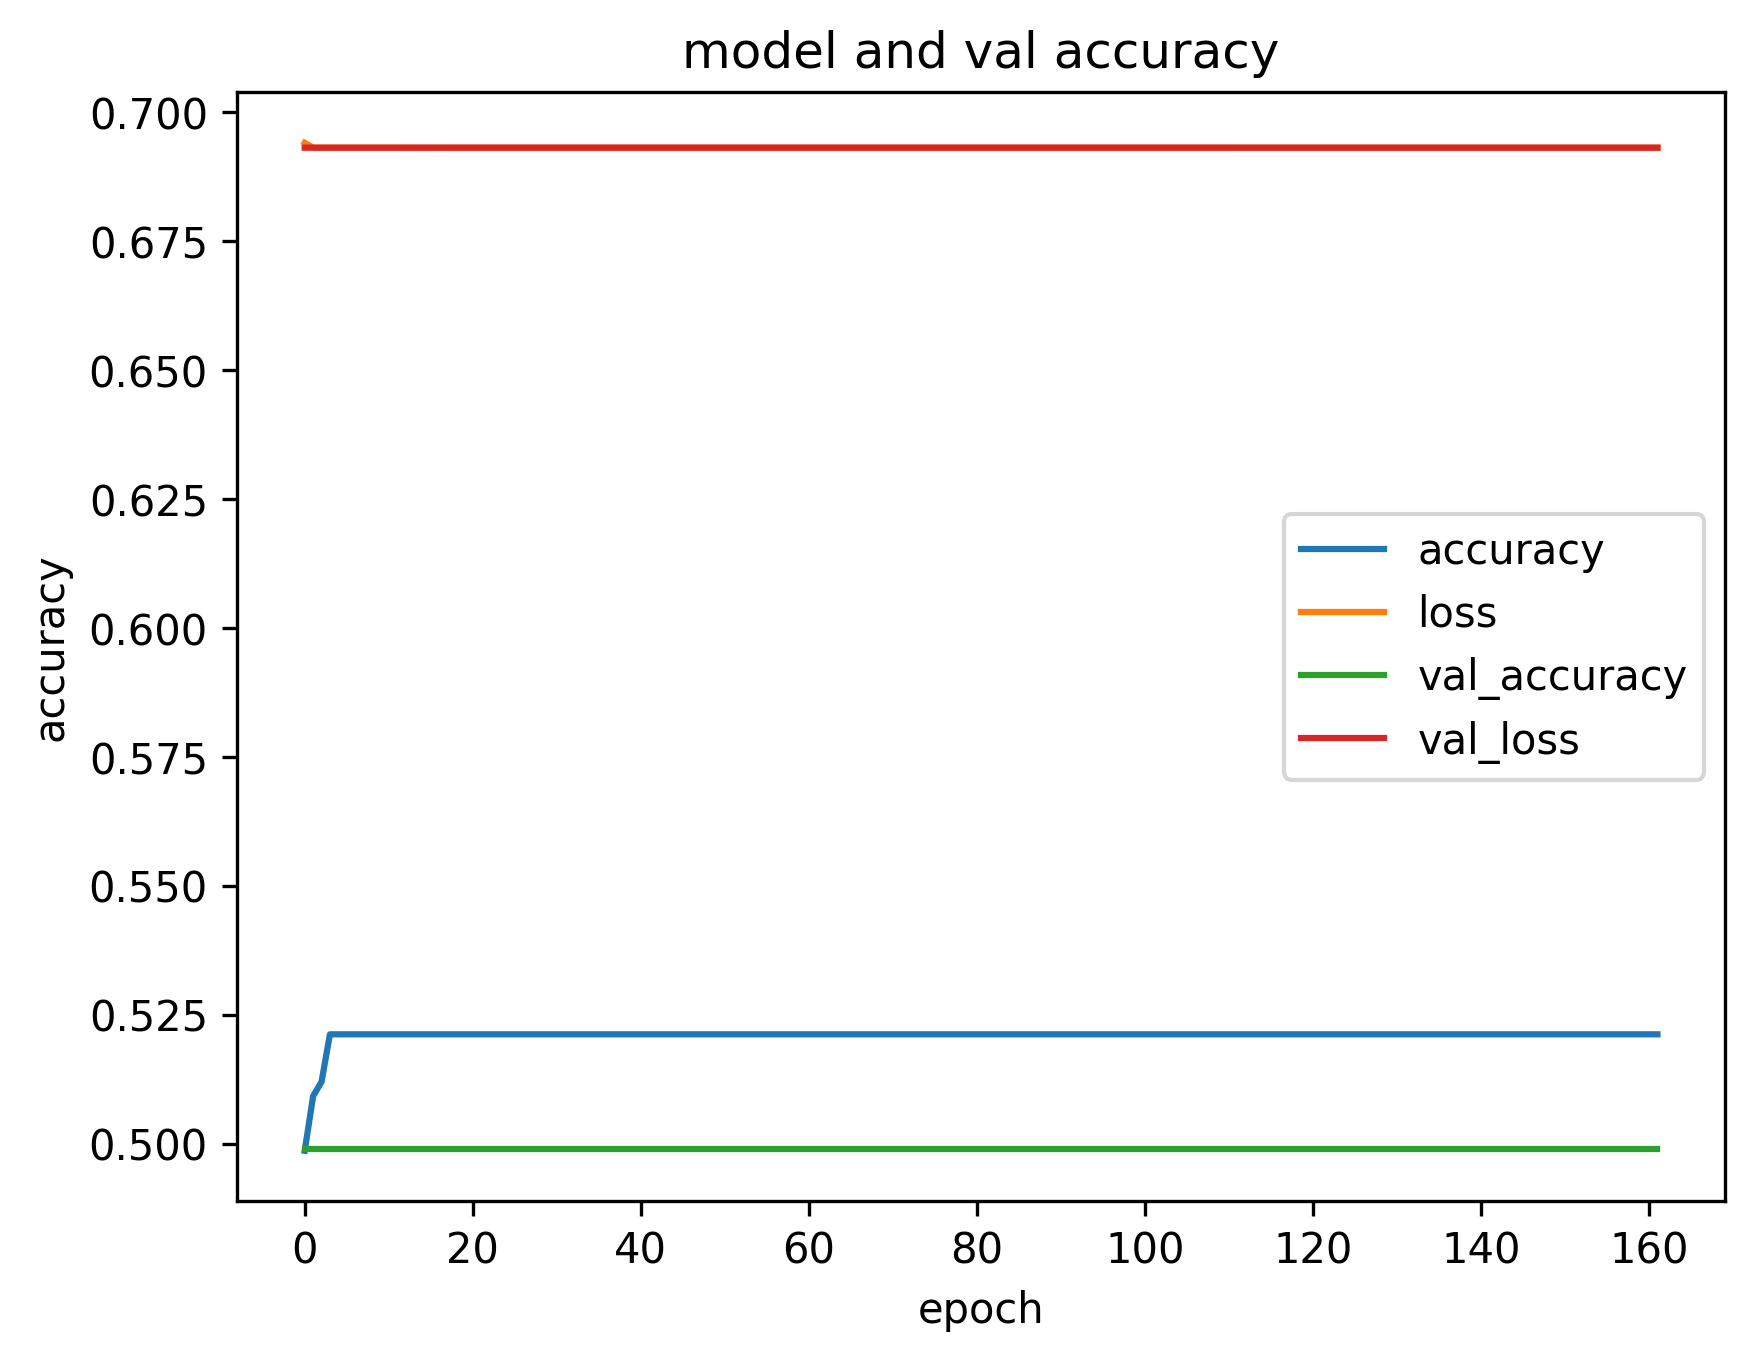

Pre-Process time=  125.30333089828491
fig=  beta dataset=  Necker cube
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 3335251989485319948
xla_global_id: -1
]


2023-11-24 23:28:37.703462: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
The PostScript backend does not support transparency; partially transparent artists will

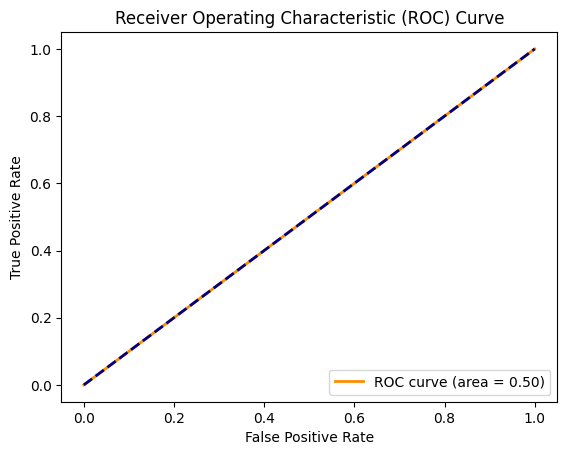

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


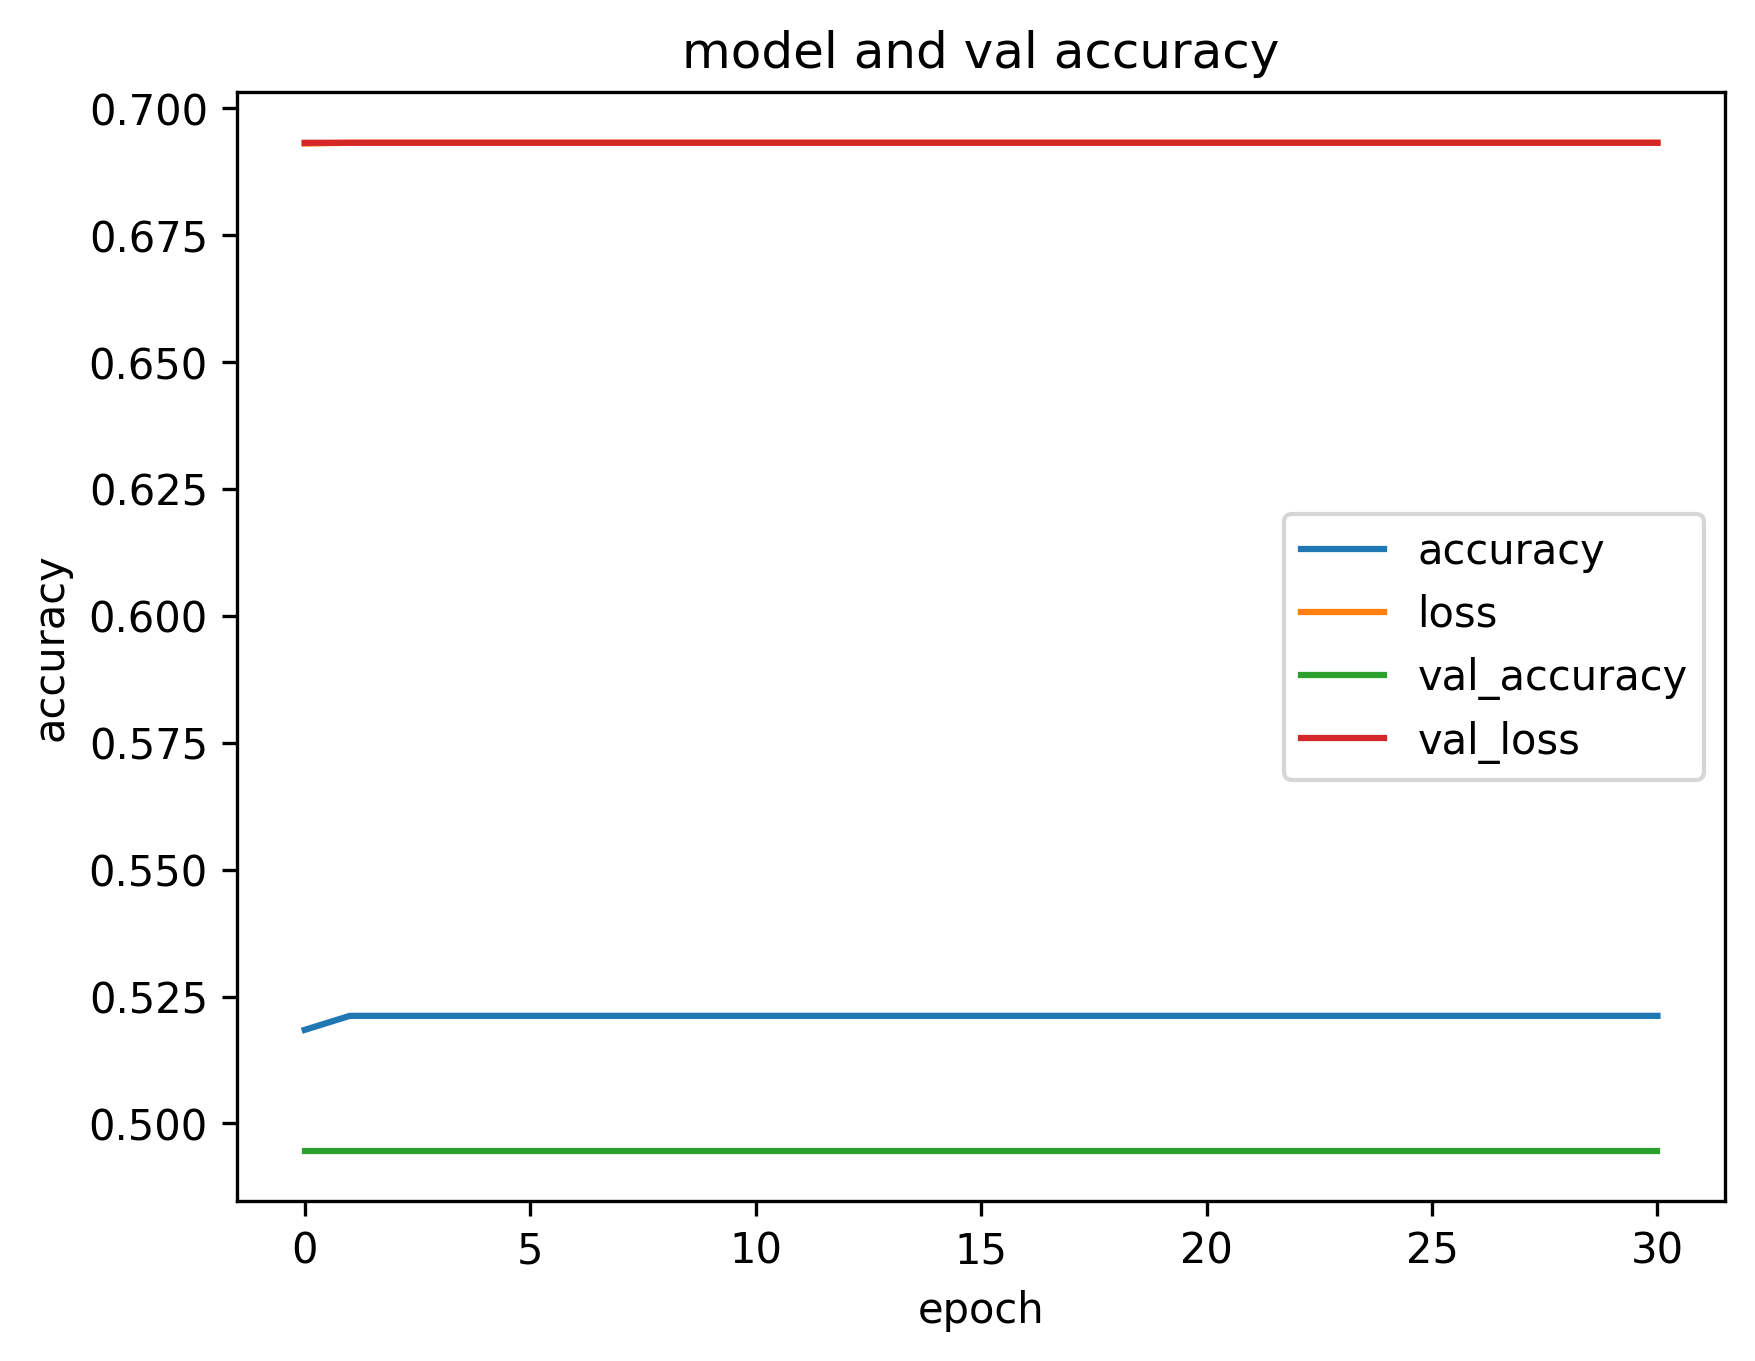

Pre-Process time=  128.24718976020813
fig=  gamma dataset=  Necker cube
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 7435629495298160399
xla_global_id: -1
]


2023-11-25 00:09:31.745213: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2500)              37502500  
                                                                 
 batch_normalization (Batch  (None, 2500)              10000     
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 1000)              2501000   
                                                                 
 batch_normalization_1 (Bat  (None, 1000)              4000      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 500)               500500    
                                                                 
 batch_normalization_2 (Bat  (None, 500)               2

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
The PostScript backend does not support transparency; partially transparent artists will

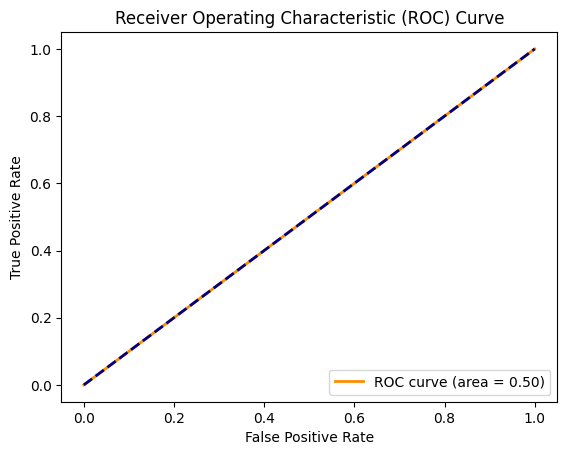

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


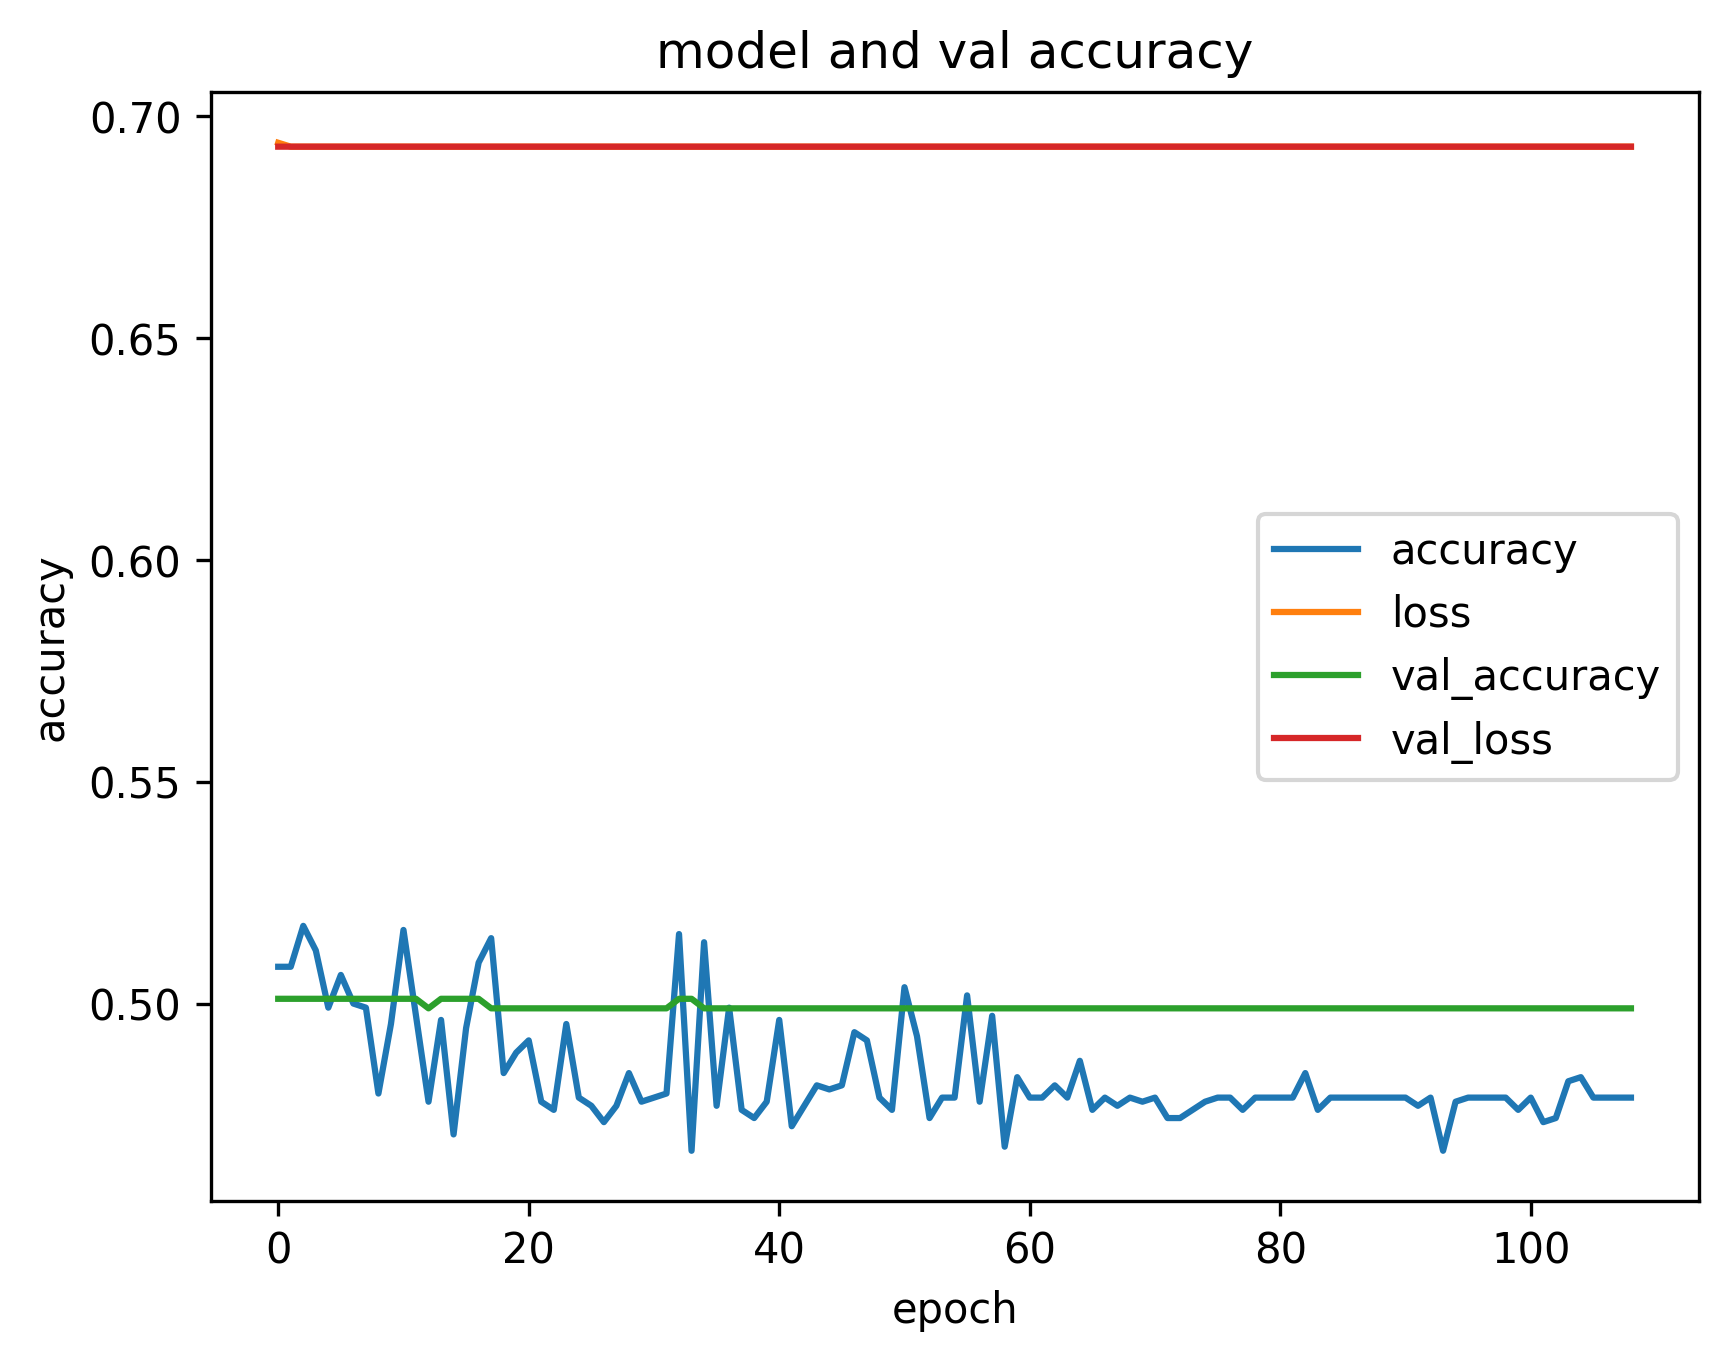

In [24]:
datasets = ["Mona Lisa", "Necker cube"]
signal_fiq_s = ['delta','theta','alpha','beta','gamma']
user = 11 
df_result = pd.DataFrame()
for dataset in datasets:
    for signal_fiq in signal_fiq_s:
        df = pd.DataFrame()
        t0 = time.time()
        for U in range(1,user):
            data= createdataframe(U,dataset,signal_fiq)
            df = pd.concat([df,data], ignore_index=True)   
        t1 = time.time()
        PreProcesstime = t1-t0
        print("Pre-Process time= ",PreProcesstime)
        print("fig= ",signal_fiq,'dataset= ',dataset)
        name = "FTRL_" + signal_fiq + "_" + dataset
        df = create_binary(df)
        model,X_test,metrics_dict = run_model(df,name)
        metrics_dict['signal_fiq'] = signal_fiq
        metrics_dict['dataset'] = dataset
        metrics_dict["PreProcesstime"] = PreProcesstime
        output_folder = 'SAVE_MODEL'
        if not os.path.exists(output_folder):
            os.makedirs(output_folder, exist_ok=True)

        savefilename = 'SAVE_MODEL/' + name +'.keras'
        model.save(savefilename)
        varfile = 'SAVE_MODEL/' + name + '.npy'
        np.save(varfile,X_test)
       # SHAP_plt(model,X_test,name) 
        metrics_df = pd.DataFrame([metrics_dict])
        df_result = pd.concat([df_result,metrics_df], ignore_index=True)   
        df_result.to_csv('FTRL_output.csv', index=False)

        
    





In [25]:
# model,X_test,name,metrics_dict

In [26]:

# shap.initjs()
# e = shap.Explainer(model, X_test)
# shap_values = e.shap_values(X_test[1:5])
# shap.summary_plot(shap_values,X_test)

In [27]:
# import shap
# import matplotlib.pyplot as plt
# import os

# def SHAP_plt_test(model, X_test, file_name,Background):
#     shap.initjs()
#     # Assuming your model is named 'model' and X_test contains the test data
#     # Use a specific masker, such as the Tabular masker for tabular data
#  #   masker = shap.maskers.Independent(X_test)
    
#     explainer = shap.Explainer(model,X_test,Background)
#     shap_values = explainer.shap_values(X_test[1:5])

#     # Generate summary plot with higher DPI for better quality (e.g., 300 DPI)
#     fig, ax = plt.subplots(dpi=300)
#     shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=20)  # Set max_display to the number of features you want to display

#     # Customize the plot if needed
#     plt.title('SHAP Summary Plot')  # Add your desired title
#     plt.xlabel('SHAP Value')  # Add your desired x-axis label
#     plt.ylabel('Feature Names')  # Add your desired y-axis label

#     # Save the customized plot as an EPS file with maximum SPI (Scalable PostScript Interchange)
#     file_save_name = 'SHAP_PLOT/' + 'SHAP_' + file_name + '.eps'
#     output_folder = 'SHAP_PLOT'
#     if not os.path.exists(output_folder):
#         os.makedirs(output_folder, exist_ok=True)
#     plt.savefig(file_save_name, format='eps', bbox_inches='tight', pad_inches=0.1)
#     plt.show()
#     return 0


In [28]:
# import os
# import numpy as np
# base = "/root/code/"
# S = os.path.join(base, "Participant 1/Background/Backgr_1.dat")
# Background = np.loadtxt(S)
# Background

In [29]:
# Background.shape

In [30]:
# [a,b]=Background[1:15000,1:31].shape
# a,b

In [31]:
# datasets = ["Mona Lisa"]
# signal_fiq_s = ['delta']
# user = 11 
# df_result = pd.DataFrame()
# for dataset in datasets:
#     for signal_fiq in signal_fiq_s:
#         df = pd.DataFrame()
#         t0 = time.time()
#         for U in range(1,user):
#             data= createdataframe(U,dataset,signal_fiq)
#             df = pd.concat([df,data], ignore_index=True)   
#         t1 = time.time()
#         PreProcesstime = t1-t0
#         print("Pre-Process time= ",PreProcesstime)
#         print("fig= ",signal_fiq,'dataset= ',dataset)
#         name = signal_fiq + "_" + dataset
#         df = create_binary(df)
#         model,X_test,metrics_dict = run_model(df,name)
#         [a,b] = X_test.shape
#         Background = Background[1:a,1:b]
#         SHAP_plt_test(model,X_test,name,Background) 


        
# model,X_test    





In [32]:
# [a,b] = X_test.shape
# Background = Background[1:a+1,1:b+1]
# SHAP_plt_test(model,X_test,name,Background)

In [33]:
# model.summary()

In [34]:
# model.save('text.keras')